# Discrete $c$-Transform as a Lower Envelope

This notebook generates `fig:dual-c-transform-envelope`.  When the source space is finite, the $c$-transform is the pointwise lower envelope
$$
    f^c(y)=\min_i c(x_i,y)-f_i.
$$
The figure compares three ground costs $c_p(x,y)=|x-y|^p$ with $p=1,2,4$.  Each gray curve is one translated cost function, and the colored lower envelope is the best-response potential.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY,
    DIRAC_MARKER_SIZE, setup_matplotlib, figure_dir, save_pdf,
    box_axes, interp_color,
)

setup_matplotlib()

NAME = "dual-c-transform-envelope"
OUT = figure_dir(NAME)


## Four source atoms and three costs

We keep the same four red source atoms for all panels.  Only the exponent $p$ changes, so the reader can see how the geometry of the lower envelope changes from piecewise-linear to increasingly sharp polynomial arcs.

In [2]:

x = np.array([-2.15, -0.78, 0.55, 1.82])
f = np.array([0.20, -0.34, 0.16, -0.05])
y = np.linspace(-3.05, 3.05, 900)
exponents = [1, 2, 4]


## Export one PDF panel per exponent

The panels have boxed axes because they show functions, but the axis labels are intentionally omitted.  Panel titles and the explanation of the semi-discrete setting are added in LaTeX.

In [3]:

def envelope_for_power(p):
    curves = np.abs(y[None, :] - x[:, None])**p - f[:, None]
    env = curves.min(axis=0)
    active = curves.argmin(axis=0)
    return curves, env, active

for p in exponents:
    curves, env, active = envelope_for_power(p)
    fig, ax = plt.subplots(figsize=(2.35, 1.82))

    for i in range(len(x)):
        ax.plot(y, curves[i], color=LIGHT_GRAY, lw=0.72, alpha=0.95, zorder=1)

    for i in range(len(x)):
        mask = active == i
        if mask.any():
            ax.plot(y[mask], env[mask], color=interp_color(i/(len(x)-1)), lw=1.65, zorder=3)

    ax.scatter(
        x, -f, s=DIRAC_MARKER_SIZE * 0.82, marker="o",
        color=RED, edgecolor="none", linewidth=0, zorder=4,
    )

    ymin = env.min() - 0.20
    ymax = min(np.percentile(curves, 67), env.max() + 3.05)
    if ymax <= ymin + 0.4:
        ymax = ymin + 0.4
    ax.set_xlim(y.min(), y.max())
    ax.set_ylim(ymin, ymax)
    ax.tick_params(labelbottom=False, labelleft=False)
    box_axes(ax)
    save_pdf(fig, OUT / f"p{p}.pdf", pad_inches=0.055)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


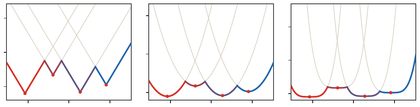

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/dual-c-transform-envelope.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/dual-c-transform-envelope.png")
display(Image(filename=str(_thumb)))
